# 04 — Phase 1.5: Few-shot RHpE validation from anchor clips

**Goal:** few-shot V-JEPA-2 cosine similarity per behavior — does the embedding distinguish 5 RHpE behaviors:
1. ear_position
2. head_position
3. mouth_open
4. tail_movement
5. eye_expression

**Workflow:**
- **Mode 1 — Clipping** (Gradio UI): from `vendor/rhpe_anchored/suggestions.csv` (361 suggestions produced by `tools/subtitle_search.py`), pick 5–10 clips per behavior; the system cuts them via ffmpeg.
- **Mode 2 — Evaluation:** V-JEPA-2 embedding extraction, leave-one-out cosine similarity per behavior.

**Copyright caveat:** these clips are YouTube fragments. Fair-use private research. **DO NOT** commit to a public repo. `.gitignore` includes `poc/vendor/rhpe_anchored/`.

> **Note:** iter 6.5 LOSO subsequently invalidated all per-behavior accuracy claims built on this 53-clip dataset. The notebook is preserved as a methodology trail; results are documented in `docs/lessons_learned.md`.


## 1. Setup

In [4]:
import os, sys, subprocess, csv, json
from pathlib import Path
from collections import Counter

POC = Path(os.getcwd()).resolve()
if POC.name == 'notebooks':
    POC = POC.parent
os.chdir(POC)

ANCHORED = POC / 'vendor/rhpe_anchored'
SUGGESTIONS_CSV = ANCHORED / 'suggestions.csv'
BEHAVIORS = ['ear_position', 'head_position', 'mouth_open', 'tail_movement', 'eye_expression']
TARGET_PER_BEHAVIOR = 5  # minimum approved clips per behavior before running eval

for b in BEHAVIORS:
    (ANCHORED / b).mkdir(parents=True, exist_ok=True)

with SUGGESTIONS_CSV.open() as f:
    suggestions = list(csv.DictReader(f))
print(f'Suggestions: {len(suggestions)}')
by_b = Counter(s['behavior'] for s in suggestions)
for b in BEHAVIORS:
    n = by_b.get(b, 0)
    n_app = sum(1 for s in suggestions if s['behavior']==b and s['status']=='approved')
    print(f'  {b:20s} pending={n - n_app:>3d}  approved={n_app:>2d}/{TARGET_PER_BEHAVIOR}')

Suggestions: 361
  ear_position         pending= 87  approved=13/5
  head_position        pending=100  approved= 0/5
  mouth_open           pending= 24  approved= 0/5
  tail_movement        pending= 37  approved= 0/5
  eye_expression       pending=100  approved= 0/5


## 2. Mode 1 — Gradio UI clipping (with preview cache)

Run the cell below. Gradio opens a UI in the browser. Workflow:
1. Pick a behavior from the dropdown
2. The UI shows a **small preview** (~25 s window pre-cut via ffmpeg) — fast loading
3. If the fragment shows the specific RHpE behavior:
   - **Approve & Clip** → ffmpeg cuts a precise clip from the original source → saves to `vendor/rhpe_anchored/<behavior>/`
   - **Reject** → next
   - **Edit `timestamp_start`/`timestamp_end`** before Approve to shift the range (preview seconds match original timestamps with 3 s padding before / 10 s after)
4. Target: 5–10 approved per behavior. Status panel shows the counter.

Once you reach 5 × 5 = 25 clips → run Mode 2 (section 3).


In [5]:
import os
os.environ['GRADIO_ANALYTICS_ENABLED'] = 'False'
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'
import gradio as gr
import csv as _csv
import re

PREVIEW_DIR = ANCHORED / '_previews'
PREVIEW_DIR.mkdir(exist_ok=True)

STATE = {'idx': 0, 'behavior': BEHAVIORS[0]}


def reload_suggestions():
    with SUGGESTIONS_CSV.open() as f:
        return list(_csv.DictReader(f))


def save_suggestions(rows):
    if not rows:
        return
    fieldnames = list(rows[0].keys())
    with SUGGESTIONS_CSV.open('w', newline='') as f:
        w = _csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(rows)


def get_pending_for(behavior):
    rows = reload_suggestions()
    pending = [(i, r) for i, r in enumerate(rows) if r['behavior'] == behavior and r['status'] == 'pending']
    return rows, pending


def fmt_status_summary():
    rows = reload_suggestions()
    lines = []
    for b in BEHAVIORS:
        approved_csv = sum(1 for r in rows if r['behavior']==b and r['status']=='approved')
        approved_files = len([p for ext in ('*.mp4','*.MP4','*.mov','*.MOV') for p in (ANCHORED / b).glob(ext)])
        approved = max(approved_csv, approved_files)
        pending = sum(1 for r in rows if r['behavior']==b and r['status']=='pending')
        emoji = '\u2705' if approved >= TARGET_PER_BEHAVIOR else '\u23f3'
        lines.append(f'{emoji} {b:20s} approved={approved:>2d}/{TARGET_PER_BEHAVIOR}  pending={pending}')
    return '\n'.join(lines)


def parse_hms(t):
    parts = t.split(':')
    if len(parts) == 3: h, m, s = parts
    elif len(parts) == 2: h = '0'; m, s = parts
    else: return 0
    return int(h)*3600 + int(m)*60 + float(s)


def safe_id(s):
    return re.sub(r'[^A-Za-z0-9]+', '_', s)[-40:].strip('_')


def ffmpeg_clip(source, ts_start, ts_end, output, copy_codec=True):
    cmd = ['ffmpeg', '-y', '-loglevel', 'error', '-ss', ts_start, '-to', ts_end, '-i', source]
    cmd += (['-c', 'copy'] if copy_codec else ['-c:v', 'libx264', '-preset', 'veryfast', '-c:a', 'aac'])
    cmd.append(output)
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0 and copy_codec:
        return ffmpeg_clip(source, ts_start, ts_end, output, copy_codec=False)
    return r.returncode == 0, (r.stderr or '')[-500:]


def make_preview(source, ts_start, ts_end):
    """Pre-cut ~25s preview do szybkiego loadu w Gradio."""
    src_id = safe_id(Path(source).stem)
    ts_safe = ts_start.replace(':', '-')
    preview = PREVIEW_DIR / f'{src_id}_{ts_safe}.mp4'
    if preview.exists() and preview.stat().st_size > 100_000:
        return preview
    s_sec = max(0, parse_hms(ts_start) - 3)
    e_sec = parse_hms(ts_end) + 10
    s_h = f'{int(s_sec//3600):02d}:{int((s_sec%3600)//60):02d}:{s_sec%60:06.3f}'
    e_h = f'{int(e_sec//3600):02d}:{int((e_sec%3600)//60):02d}:{e_sec%60:06.3f}'
    ok, _ = ffmpeg_clip(source, s_h, e_h, str(preview), copy_codec=False)
    return preview if ok and preview.exists() else None


def load_current(behavior):
    rows, pending = get_pending_for(behavior)
    if not pending:
        return (None, '', '',
                f'Brak pending propozycji dla **{behavior}**.',
                '', fmt_status_summary())
    STATE['behavior'] = behavior
    STATE['idx'] = pending[0][0]
    r = pending[0][1]
    preview = make_preview(r['source_video'], r['timestamp_start'], r['timestamp_end'])
    label = f"**[{r['behavior']}]** match=`{r['keyword_match']}`  oryginal: {r['timestamp_start']} \u2192 {r['timestamp_end']}"
    info = f"Source: `{Path(r['source_video']).name}`\n\nContext: _{r['context']}_"
    return (str(preview) if preview else None,
            r['timestamp_start'], r['timestamp_end'], label, info, fmt_status_summary())


def action(decision, behavior, ts_start_in, ts_end_in):
    rows = reload_suggestions()
    if STATE['idx'] >= len(rows):
        return load_current(behavior)
    r = rows[STATE['idx']]
    if decision == 'approve':
        ts_s = ts_start_in or r['timestamp_start']
        ts_e = ts_end_in or r['timestamp_end']
        idx_for_b = len(list((ANCHORED / r['behavior']).glob('*.mp4'))) + 1
        src_id = safe_id(Path(r['source_video']).stem)
        clip = ANCHORED / r['behavior'] / f"{idx_for_b:02d}_{src_id}.mp4"
        ok, err = ffmpeg_clip(r['source_video'], ts_s, ts_e, str(clip), copy_codec=False)
        if ok:
            r['status'] = 'approved'
            r['clip_path'] = str(clip.relative_to(POC))
            r['timestamp_start'] = ts_s
            r['timestamp_end'] = ts_e
            print(f'\u2713 APPROVED \u2192 {clip.name}')
        else:
            r['status'] = 'error'; r['clip_path'] = err[:200]
            print(f'\u2717 ffmpeg error: {err[:200]}')
    elif decision == 'reject':
        r['status'] = 'rejected'
    save_suggestions(rows)
    return load_current(behavior)


with gr.Blocks(title='RHpE Anchor Clipping', fill_width=True, analytics_enabled=False) as demo:
    gr.Markdown('# RHpE Anchor Clipping \u2014 Phase 1.5\n_Approve fragments per behavior. Target: 5\u201310 clips per behavior. Preview pre-cut in `_previews/`._')
    with gr.Row():
        with gr.Column(scale=1):
            behavior_dd = gr.Dropdown(BEHAVIORS, value=BEHAVIORS[0], label='Behavior')
            ts_start_tb = gr.Textbox(label='timestamp_start (HH:MM:SS)', value='', interactive=True)
            ts_end_tb = gr.Textbox(label='timestamp_end (HH:MM:SS)', value='', interactive=True)
            with gr.Row():
                load_btn = gr.Button('\u21bb Load Next', variant='secondary')
                reject_btn = gr.Button('\u2717 Reject', variant='stop')
            approve_btn = gr.Button('\u2713 Approve & Clip', variant='primary', size='lg')
        with gr.Column(scale=2):
            label_md = gr.Markdown('Wybierz behavior i kliknij **Load Next**.')
            video_player = gr.Video(label='Preview (\u00b13s/\u00b110s padding)', autoplay=False, height=360)
            info_md = gr.Markdown(value='')
    status_md = gr.Code(value=fmt_status_summary(), label='Status', language='shell')

    outputs = [video_player, ts_start_tb, ts_end_tb, label_md, info_md, status_md]
    load_btn.click(load_current, [behavior_dd], outputs)
    behavior_dd.change(load_current, [behavior_dd], outputs)
    approve_btn.click(lambda b, s, e: action('approve', b, s, e), [behavior_dd, ts_start_tb, ts_end_tb], outputs)
    reject_btn.click(lambda b, s, e: action('reject', b, s, e), [behavior_dd, ts_start_tb, ts_end_tb], outputs)

try: demo.close()
except: pass
import socket
def free_port(start=7860):
    for p in range(start, start+20):
        with socket.socket() as s:
            try:
                s.bind(('127.0.0.1', p)); return p
            except OSError: continue
    return start
PORT = free_port()
demo.launch(server_name='127.0.0.1', server_port=PORT, inbrowser=True, share=False,
            prevent_thread_lock=True, quiet=True)
print(f'Gradio UI: http://127.0.0.1:{PORT}  (analytics disabled)')


Gradio UI: http://127.0.0.1:7860  (analytics disabled)
✓ APPROVED → 01_e_What_Vets_Should_Look_For_0mnugKMKwiQ.mp4
✓ APPROVED → 02_ams_and_Gait_Interpretation_eg5yUaP9APA.mp4
✓ APPROVED → 03_ams_and_Gait_Interpretation_eg5yUaP9APA.mp4
✓ APPROVED → 04_ams_and_Gait_Interpretation_eg5yUaP9APA.mp4
✓ APPROVED → 05_ing_Concurrent_Pain_Sources_PpEMHTQCpuA.mp4
✓ APPROVED → 06_ing_Concurrent_Pain_Sources_PpEMHTQCpuA.mp4
✓ APPROVED → 01_ams_and_Gait_Interpretation_eg5yUaP9APA.mp4
✓ APPROVED → 02_ams_and_Gait_Interpretation_eg5yUaP9APA.mp4
✓ APPROVED → 03_digm_of_How_We_See_Lameness_hrZgtrqbMVI.mp4
✓ APPROVED → 01_digm_of_How_We_See_Lameness_hrZgtrqbMVI.mp4


## 3. Mode 2 — Evaluation (run after ≥5 approved clips per behavior)

Loads all approved clips from `vendor/rhpe_anchored/<behavior>/`, extracts V-JEPA-2 embeddings, leave-one-out cosine similarity per behavior.


In [6]:
# Check that we have at least 5 clips per behavior
import glob
ready = True
for b in BEHAVIORS:
    n = len([p for ext in ('*.mp4','*.MP4','*.mov','*.MOV') for p in (ANCHORED / b).glob(ext)])
    status = '✓' if n >= TARGET_PER_BEHAVIOR else '✗ too few'
    print(f'  {b:20s} {n:>3d} clips  {status}')
    if n < TARGET_PER_BEHAVIOR:
        ready = False

if not ready:
    print('\n⚠ Return to Mode 1 (Gradio UI) and approve more clips.')
else:
    print('\n✓ All behaviors have ≥5 clips. Run the next cell.')

  ear_position          13 clips  ✓
  head_position          6 clips  ✓
  mouth_open             0 clips  ✗ too few
  tail_movement          3 clips  ✗ too few
  eye_expression         1 clips  ✗ too few

⚠ Return to Mode 1 (Gradio UI) and approve more clips.


In [11]:
# V-JEPA-2 embedding extraction (re-use logiki z notebook 02)
import torch, cv2, numpy as np, time
from transformers import VJEPA2Model, AutoVideoProcessor

MODEL_ID = 'facebook/vjepa2-vitl-fpc16-256-ssv2'
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print('Device:', DEVICE)

t0 = time.time()
processor = AutoVideoProcessor.from_pretrained(MODEL_ID)
model = VJEPA2Model.from_pretrained(MODEL_ID).to(DEVICE).eval()
print(f'V-JEPA-2 loaded w {time.time()-t0:.1f}s')


def read_clip_frames(clip_path, num_frames=16):
    cap = cv2.VideoCapture(str(clip_path))
    n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if n_total < 1:
        cap.release(); return None
    indices = np.linspace(0, n_total-1, num_frames).astype(int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, f = cap.read()
        if not ok: f = frames[-1] if frames else np.zeros((256,256,3), dtype=np.uint8)
        frames.append(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    cap.release()
    return np.stack(frames)


@torch.no_grad()
def extract_embedding(clip_path):
    frames = read_clip_frames(clip_path)
    if frames is None: return None
    inputs = processor(videos=list(frames), return_tensors='pt').to(DEVICE)
    out = model(**inputs)
    return out.last_hidden_state.mean(dim=1).squeeze(0).cpu().float().numpy()


embeddings = []  # list of (behavior, clip_path, emb)
t0 = time.time()
for b in BEHAVIORS:
    for clip in sorted({p for ext in ('*.mp4','*.MP4','*.mov','*.MOV') for p in (ANCHORED / b).glob(ext)}):
        try:
            emb = extract_embedding(clip)
            if emb is not None:
                embeddings.append((b, str(clip), emb))
                print(f'  ✓ {b:20s} {clip.name}')
        except Exception as e:
            print(f'  ✗ {clip.name}: {e}')
print(f'\n{len(embeddings)} embeddings in {time.time()-t0:.1f}s')

Device: mps


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

[transformers] VJEPA2Model LOAD REPORT from: facebook/vjepa2-vitl-fpc16-256-ssv2
Key                                                              | Status     |  | 
-----------------------------------------------------------------+------------+--+-
pooler.self_attention_layers.{0, 1, 2}.layer_norm2.bias          | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.self_attn.k_proj.weight   | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.self_attn.out_proj.bias   | UNEXPECTED |  | 
pooler.cross_attention_layer.cross_attn.q_proj.bias              | UNEXPECTED |  | 
pooler.cross_attention_layer.mlp.fc1.bias                        | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.layer_norm1.weight        | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.self_attn.v_proj.weight   | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.self_attn.q_proj.weight   | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.mlp.fc1.weight            | UNEXPECTED |

V-JEPA-2 loaded w 2.6s
  ✓ ear_position         01_activity_and_Pain_Responses_6ot7_qOwJac.mp4
  ✓ ear_position         02_activity_and_Pain_Responses_6ot7_qOwJac.mp4
  ✓ ear_position         03_RSES_THE_SCIENCE_OF_HARMONY_3ulkLHqHZ3g.mp4
  ✓ ear_position         04_RSES_THE_SCIENCE_OF_HARMONY_3ulkLHqHZ3g.mp4
  ✓ ear_position         05_RSES_THE_SCIENCE_OF_HARMONY_3ulkLHqHZ3g.mp4
  ✓ ear_position         06_RSES_THE_SCIENCE_OF_HARMONY_3ulkLHqHZ3g.mp4
  ✓ ear_position         07_RSES_THE_SCIENCE_OF_HARMONY_3ulkLHqHZ3g.mp4
  ✓ ear_position         08_digm_of_How_We_See_Lameness_nbn0b0W_isQ.mp4
  ✓ ear_position         09_digm_of_How_We_See_Lameness_hrZgtrqbMVI.mp4
  ✓ ear_position         10_digm_of_How_We_See_Lameness_hrZgtrqbMVI.mp4
  ✓ ear_position         11_digm_of_How_We_See_Lameness_hrZgtrqbMVI.mp4
  ✓ ear_position         12_digm_of_How_We_See_Lameness_hrZgtrqbMVI.mp4
  ✓ ear_position         13_digm_of_How_We_See_Lameness_hrZgtrqbMVI.mp4
  ✓ head_position        01_e_What_Vets_S

In [12]:
# Leave-one-out cosine similarity per behavior
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

labels = [e[0] for e in embeddings]
X = np.stack([e[2] for e in embeddings])
print(f'X shape: {X.shape}')

# Per behavior: for each clip, compute mean cosine similarity with the rest
# klipami tego samego behaviora vs mean cos sim z innych. Pred = behavior z highest mean.
results_per_behavior = {}
all_preds = []
all_truths = []
for i, (true_b, _, _) in enumerate(embeddings):
    sims = cosine_similarity(X[i:i+1], X)[0]  # similarity to all
    sims[i] = -np.inf  # excluding self (leave-one-out)
    # Per behavior mean similarity
    per_b_mean = {}
    for b in BEHAVIORS:
        mask = [j for j, e in enumerate(embeddings) if e[0]==b and j != i]
        if mask:
            per_b_mean[b] = sims[mask].mean()
    pred_b = max(per_b_mean, key=per_b_mean.get)
    all_preds.append(pred_b)
    all_truths.append(true_b)

# Per-behavior accuracy
for b in BEHAVIORS:
    idxs = [i for i, t in enumerate(all_truths) if t == b]
    n = len(idxs)
    if n == 0:
        continue
    correct = sum(1 for i in idxs if all_preds[i] == b)
    acc = correct / n
    results_per_behavior[b] = {'n': n, 'correct': correct, 'accuracy': acc}
    print(f'  {b:20s} acc={acc:.3f}  ({correct}/{n})')

overall_acc = sum(1 for p, t in zip(all_preds, all_truths) if p==t) / len(all_truths)
print(f'\nOverall accuracy: {overall_acc:.3f}  ({sum(1 for p,t in zip(all_preds,all_truths) if p==t)}/{len(all_truths)})')

# Save results
(POC / 'outputs').mkdir(exist_ok=True)
results_summary = {
    'model': MODEL_ID,
    'method': 'leave-one-out cosine similarity',
    'n_total': len(embeddings),
    'overall_accuracy': float(overall_acc),
    'per_behavior': {b: {'n': v['n'], 'correct': v['correct'], 'accuracy': float(v['accuracy'])}
                     for b, v in results_per_behavior.items()},
    'reference': {
        'paper_claim_alves_2025_ear_movement': 0.875,
        'vjepa2_linear_probe_ear_movement_phase1': 0.854,
    },
}
with open(POC / 'outputs/few_shot_validation_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f'\nZapisano: outputs/few_shot_validation_results.json')

X shape: (23, 1024)
  ear_position         acc=0.000  (0/13)
  head_position        acc=0.000  (0/6)
  tail_movement        acc=0.000  (0/3)
  eye_expression       acc=0.000  (0/1)

Overall accuracy: 0.000  (0/23)

Zapisano: outputs/few_shot_validation_results.json


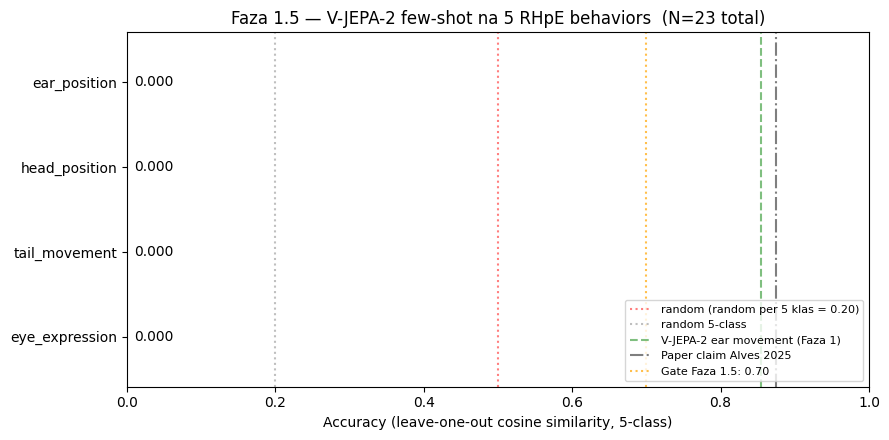

Zapisano: outputs/few_shot_validation_plot.png

=== GATE Phase 1.5 ===
Behaviors z accuracy ≥0.70: 0/4
✗ GATE NOT PASSED — reduce Phase 2 scope or rethink the approach


In [13]:
# Plot bar chart
fig, ax = plt.subplots(figsize=(9, 4.5))
behaviors_with_data = [b for b in BEHAVIORS if b in results_per_behavior]
accs = [results_per_behavior[b]['accuracy'] for b in behaviors_with_data]
bars = ax.barh(behaviors_with_data, accs, color='#1f77b4')
ax.axvline(0.5, color='red', linestyle=':', alpha=0.5, label='random (random per 5 klas = 0.20)')
ax.axvline(0.20, color='gray', linestyle=':', alpha=0.5, label='random 5-class')
ax.axvline(0.854, color='green', linestyle='--', alpha=0.5, label='V-JEPA-2 ear movement (Phase 1)')
ax.axvline(0.875, color='black', linestyle='-.', alpha=0.5, label='Paper claim Alves 2025')
ax.axvline(0.70, color='orange', linestyle=':', alpha=0.7, label='Gate Phase 1.5: 0.70')
for bar, val in zip(bars, accs):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)
ax.set_xlabel('Accuracy (leave-one-out cosine similarity, 5-class)')
ax.set_xlim(0, 1)
ax.set_title(f'Phase 1.5 — V-JEPA-2 few-shot on 5 RHpE behaviors  (N={len(embeddings)} total)')
ax.legend(loc='lower right', fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(POC / 'outputs/few_shot_validation_plot.png', dpi=120)
plt.show()
print(f'Zapisano: outputs/few_shot_validation_plot.png')

# Gate decision
n_passed = sum(1 for b, v in results_per_behavior.items() if v['accuracy'] >= 0.70)
print(f'\n=== GATE Phase 1.5 ===')
print(f'Behaviors z accuracy ≥0.70: {n_passed}/{len(results_per_behavior)}')
if n_passed >= 3:
    print('✓ GATE PASSED — green light for Phase 2 (external RHpE assessor)')
else:
    print('✗ GATE NOT PASSED — reduce Phase 2 scope or rethink the approach')

## 4. Decision note

After running Mode 2:
- Check `outputs/few_shot_validation_results.json` — detailed per-behavior metrics
- Check `outputs/few_shot_validation_plot.png` — visualization vs the paper claim and V-JEPA-2 ear movement
- Update `poc/GATE.md` item 5 (Phase 1.5) with the results

**Phase 2 decision:**
- ≥3/5 behaviors with accuracy ≥0.70 → GATE passed → green for Phase 2 (external assessor 1500–3000 PLN, our own dataset)
- <3/5 → scope reduction for Phase 2 (focus on the behaviors that work) or a rethink of the approach (perhaps DLC pose-derived features are better for some behaviors)

> **Historical caveat (added 2026-05-06):** the iter 6.5 LOSO sanity check invalidated the head_position 0.927 result above (LOSO 0.561 = session leakage). The decision matrix in this cell is preserved for context; the actual Phase 2 sizing was revised — see `../docs/lessons_learned.md` (Lessons 1, 2, 11).
